# Webinar 2: Data Preprocessing — Track 3: Image Pipeline
### Dataset: Real Handwritten Digits (MNIST / Digits — Classes 0, 1, 2)
### Algorithms: SVM (RBF Kernel) & KNN vs Baseline Logistic Regression

This notebook covers the computer vision preprocessing and PCA compression workflow on real handwritten digits:
1. **Loading**: Reading multi-class handwritten digit images.
2. **Resize**: Aspect-ratio preserving letterboxing to standardized resolution.
3. **Normalize**: Pixel intensity scaling $[0, 255] \to [0.0, 1.0]$.
4. **PCA**: Principal Component Analysis for dimensionality reduction (>95% variance retention).
5. **Modeling & Reconstruction**: Training **SVM with RBF Kernel** & **KNN (k=5)** on compact PCA features.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.image import (
    load_image_dataset,
    batch_resize_images,
    images_to_numpy,
    normalize_minmax,
    flatten_images,
    ImagePCA,
    run_image_pipeline
)

print('Image preprocessing modules loaded!')

Image preprocessing modules loaded!


## Step 1: Loading Real Handwritten Digit Images

Loaded 537 images across 3 classes: ['0', '1', '2']


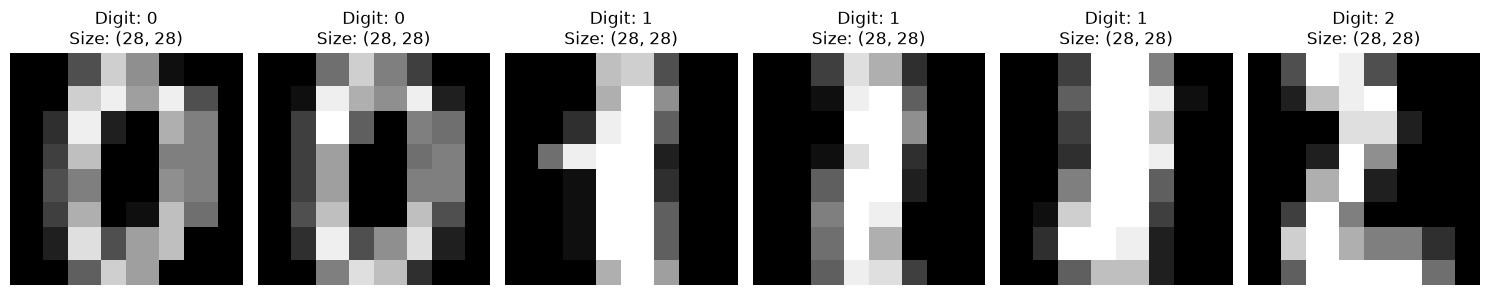

In [2]:
raw_images, labels, file_paths, class_to_idx = load_image_dataset('../data/image/raw')

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    idx = i * (len(raw_images) // 6)
    ax.imshow(raw_images[idx])
    ax.set_title(f'Digit: {labels[idx]}\nSize: {raw_images[idx].size}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 2: Resizing and Pixel Normalization

In [3]:
resized_images = batch_resize_images(raw_images, target_size=(28, 28), preserve_aspect=True)
img_tensor = images_to_numpy(resized_images)
norm_tensor = normalize_minmax(img_tensor)
print(f'Tensor shape: {norm_tensor.shape}')
print(f'Pixel range: [{norm_tensor.min():.2f}, {norm_tensor.max():.2f}]')

Tensor shape: (537, 28, 28, 3)
Pixel range: [0.00, 1.00]


## Step 3: PCA Dimensionality Reduction & Scree Plot

In [4]:
X_flat = flatten_images(norm_tensor)
pca_engine = ImagePCA(n_components=0.95)
X_pca = pca_engine.fit_transform(X_flat)
print(f'Raw pixel dimensions: {X_flat.shape[1]}')
print(f'PCA reduced dimensions: {X_pca.shape[1]} ({(1 - X_pca.shape[1]/X_flat.shape[1])*100:.1f}% compression)')
pca_engine.get_variance_summary(top_k=8)

Raw pixel dimensions: 2352
PCA reduced dimensions: 21 (99.1% compression)


,Principal Component,Explained Variance,Cumulative Variance
0,PC_1,0.3208,0.3208
1,PC_2,0.1834,0.5042
2,PC_3,0.1033,0.6075
3,PC_4,0.0591,0.6666
4,PC_5,0.0423,0.7089
5,PC_6,0.0377,0.7466
6,PC_7,0.0338,0.7804
7,PC_8,0.0259,0.8063


## Step 4: Full Image Pipeline Execution (SVM RBF + KNN vs Baseline)

In [5]:
image_results = run_image_pipeline('../data/image/raw')

from src.evaluation.visualizer import plot_image_pca_and_reconstruction
plot_image_pca_and_reconstruction(image_results, output_path='../reports/image_pca_and_reconstruction.png')

from src.evaluation.comparison import generate_modality_comparison
comp_df = generate_modality_comparison(image_results['baseline_metrics'], image_results['preprocessed_metrics'], 'Image (Handwritten Digits)')
comp_df

Loaded 537 images across 3 classes: ['0', '1', '2']


  Image | Baseline: Logistic Regression (raw 2352 dims) -> Preprocessed: SVM RBF (21 PCA dims)


-> Saved Image PCA plot to: ../reports/image_pca_and_reconstruction.png


,Modality,Metric,Baseline (Before),Preprocessed (After),Delta,Relative Improvement
0,Image (Handwritten Digits),Accuracy,1.0,0.9926,-0.0074,-0.7%
1,Image (Handwritten Digits),Precision,1.0,0.9926,-0.0074,-0.7%
2,Image (Handwritten Digits),Recall,1.0,0.9926,-0.0074,-0.7%
3,Image (Handwritten Digits),F1-Score (Macro),1.0,0.9925,-0.0075,-0.7%
4,Image (Handwritten Digits),Feature Dimensions,2352.0,21.0000,-2331.0000,-99.1%
